In [1]:
import xarray as xr
import numpy as np 
import scipy
import os
import xeofs
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
from sklearn.decomposition import PCA

import pandas as pd
import string
from src import config_cesm
from src.utils import util_cesm
from src.models.diagnostics import roll_metric
reference_grid = util_cesm.generate_sps_grid()
CNAMES = ["input2", "input3a", "input3b", "input3c", "input3d", "input4"]

prc_data_dir = Path(config_cesm.PROCESSED_DATA_DIRECTORY)

def add_hatching(ax, significance_mask, x_edges, y_edges, hatch='///', edgecolor='k'):
    Ny, Nx = significance_mask.shape

    for i in range(Ny):
        for j in range(Nx):
            if significance_mask[i, j]:
                rect = mpatches.Rectangle(
                    (x_edges[j], y_edges[i]),
                    x_edges[j+1] - x_edges[j],
                    y_edges[i+1] - y_edges[i],
                    hatch=hatch,
                    fill=False,
                    edgecolor=edgecolor,
                    linewidth=0
                )
                ax.add_patch(rect)

def plot_markers(ax, exceeds_persistence, x_centers, y_centers):
    for i in range(6):
        for j in range(12):
            if not exceeds_persistence[i,j]:
                ax.plot(x_centers[j], y_centers[i], '.k', markersize=4) 

In [2]:
acc = {}
acc_agg = {}
significance_ds = {}

input_configs_extended = CNAMES + ["input3e", "input3f", "input4a"]

for cname in input_configs_extended:
    acc_agg[cname] = xr.open_dataset(
        os.path.join(config_cesm.PREDICTIONS_DIRECTORY, f"exp1_{cname}", "diagnostics/acc_agg.nc")
    )["acc"]
    acc[cname] = xr.open_dataset(
        os.path.join(config_cesm.PREDICTIONS_DIRECTORY, f"exp1_{cname}", "diagnostics/acc.nc")
    )["acc"]

for cname in input_configs_extended:
    if cname == "input2":
        continue

    significance_ds[cname] = xr.open_dataset(
        os.path.join(config_cesm.ANALYSIS_RESULTS_DIRECTORY, f"confidence_intervals/exp1_input2_exp1_{cname}_acc.nc")
    )


<>:34: SyntaxWarning: invalid escape sequence '\D'
<>:34: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_16469/3793668958.py:34: SyntaxWarning: invalid escape sequence '\D'
  ax.set_title(f"$\Delta$ ACC: add {input_added_extended[i]}",


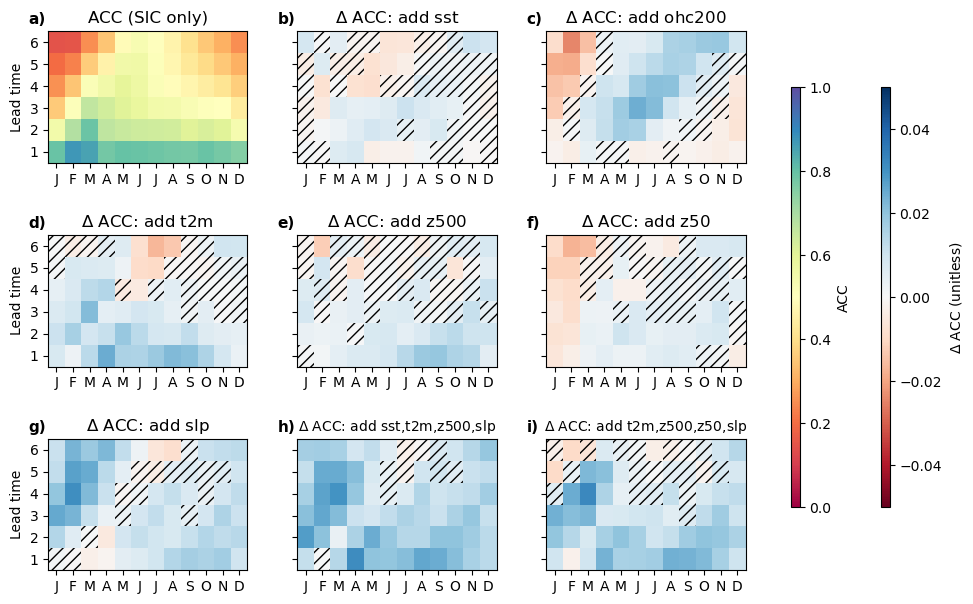

In [3]:
P_VALUE_CUTOFF = 0.05

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(9, 7), sharey=True)

x = np.arange(13)
y = np.arange(7)
x_centers = (x[:-1] + x[1:]) / 2
y_centers = (y[:-1] + y[1:]) / 2

acc_input2 = acc_agg["input2"].mean("nn_member_id")
input_configs_extended_plot = ["input3a", "input3f", "input3d", "input3c", "input3e", "input3b", "input4", "input4a"]
input_added_extended = ["sst", "ohc200", "t2m", "z500", "z50", "slp", "sst,t2m,z500,slp", "t2m,z500,z50,slp"]

axs = axs.flatten()
cax2 = axs[0].pcolormesh(x, y, acc_input2, cmap="Spectral", shading="flat", vmin=0, vmax=1)
axs[0].set_yticks(y_centers, labels=np.arange(1, 7, 1))
axs[0].set_ylabel("Lead time")
axs[0].set_title("ACC (SIC only)")
axs[0].set_xticks(x_centers, labels=["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])

for i, ax in enumerate(axs[1:]):
    if i >= len(input_configs_extended_plot):
        ax.set_visible(False)
        continue
    input_config = input_configs_extended_plot[i]
    cax = ax.pcolormesh(
        x, y, acc_agg[input_config].mean("nn_member_id") - acc_input2,
        cmap="RdBu", shading="flat", vmin=-0.05, vmax=0.05
    )
    significance_mask = (significance_ds[input_config].p_value > P_VALUE_CUTOFF).astype(int)
    add_hatching(ax, significance_mask, x, y)
    ax.set_xticks(x_centers, labels=["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
    ax.set_yticks(y_centers, labels=np.arange(1, 7, 1))
    ax.set_title(f"$\Delta$ ACC: add {input_added_extended[i]}",
                fontsize = 10 if input_config in ["input4", "input4a"] else 12)

axs[3].set_ylabel("Lead time")
axs[6].set_ylabel("Lead time")

cbar_ax = fig.add_axes([0.95, 0.2, 0.01, 0.6])
cbar_ax2 = fig.add_axes([1.05, 0.2, 0.01, 0.6])

plt.colorbar(cax, cax=cbar_ax2, label=r'$\Delta$ ACC (unitless)', orientation="vertical")
plt.colorbar(cax2, cax=cbar_ax, label=r'ACC', orientation="vertical")

plt.subplots_adjust(hspace=0.55, wspace=0.25)

panel_labels = list(string.ascii_lowercase)
for i, ax in enumerate(axs):
    if ax.get_visible():
        ax.annotate(
            f"{panel_labels[i]})", xy=(0, 1), xycoords="axes fraction",
            xytext=(-0.1, 1.03), textcoords="axes fraction",
            ha="left", va="bottom", fontsize=11, fontweight="bold"
        )

plt.savefig("figures/cesm_new/exp1_ACC_absolute_extended.pdf", bbox_inches="tight")


<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_16469/2744433239.py:16: SyntaxWarning: invalid escape sequence '\D'
  ax.set_title(f"$\Delta$ ACC: add {input_added_extended[i]}",


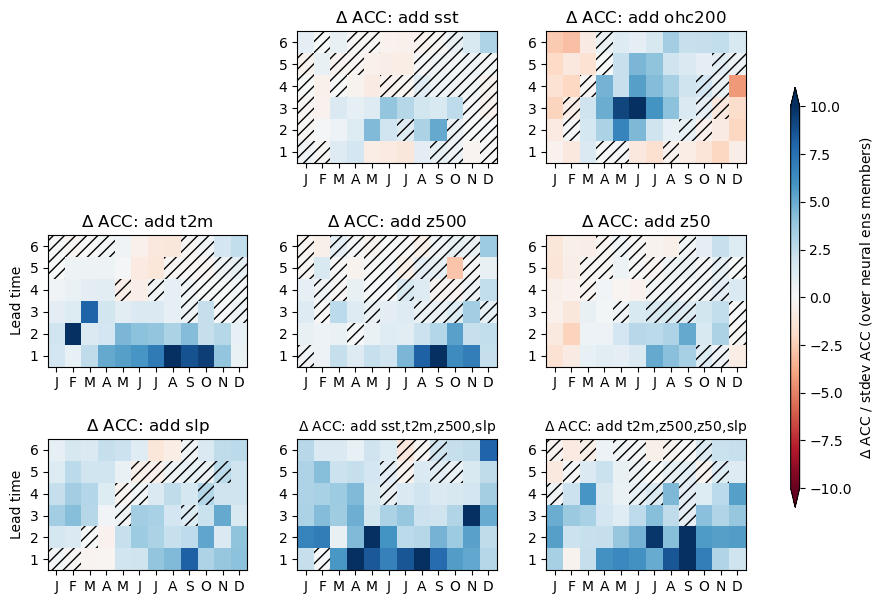

In [4]:
input_configs_extended_plot = ["input3a", "input3f", "input3d", "input3c", "input3e", "input3b", "input4", "input4a"]
input_added_extended = ["sst", "ohc200", "t2m", "z500", "z50", "slp", "sst,t2m,z500,slp", "t2m,z500,z50,slp"]

fig, axs = plt.subplots(3, 3, figsize=(9, 7))
axs = axs.flatten()
for i, input_config in enumerate(input_configs_extended_plot):
    ax = axs[i+1]
    cax = ax.pcolormesh(
        x, y, (acc_agg[input_config].mean("nn_member_id") - acc_input2) / acc_agg[input_config].std("nn_member_id"),
        cmap="RdBu", shading="flat", vmin=-10, vmax=10
    )
    significance_mask = (significance_ds[input_config].p_value > P_VALUE_CUTOFF).astype(int)
    add_hatching(ax, significance_mask, x, y)
    ax.set_xticks(x_centers, labels=["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
    ax.set_yticks(y_centers, labels=np.arange(1, 7, 1))
    ax.set_title(f"$\Delta$ ACC: add {input_added_extended[i]}",
                fontsize = 10 if input_config in ["input4", "input4a"] else 12)

axs[0].remove()
axs[3].set_ylabel("Lead time")
axs[6].set_ylabel("Lead time")

cbar_ax = fig.add_axes([0.95, 0.2, 0.01, 0.6])

plt.colorbar(cax, cax=cbar_ax, 
            label=r'$\Delta$ ACC / stdev ACC (over neural ens members)', 
            orientation="vertical",
            extend='both')

plt.subplots_adjust(hspace=0.55, wspace=0.25)
plt.savefig("figures/cesm_new/exp1_ACC_div_stdev.png", bbox_inches="tight", dpi=300)
